In [1]:
import os
import PIL
device='cuda'
from PIL import Image
from torch.utils.data import Dataset,DataLoader
from torch.nn import Module
from torch.optim import AdamW
import json
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms
from random import randint,choice

In [2]:
alphabet=[symb for symb in '_ABEKMHOPCTYX0123456789']
let2int={i:let for let,i in enumerate(alphabet)}
int2let={let:i for let,i in enumerate(alphabet)}

In [3]:
# backgroud_trans=transforms.Compose([
#     transforms.Resize((128,256)),
# ])

# img_trans=transforms.Compose([
#     transforms.Resize((64,128)),
# ])




# background=backgroud_trans(Image.open('/home/artemybombastic/Downloads/dohod.jpg'))
# img=img_trans(Image.open('/home/artemybombastic/MyGit/VehicleNumberData/VNR_Data/train/img/A406OA37.png'))

# background.paste(img,(randint(0,180),randint(0,80)))
# background

In [9]:
class NumberDataset(Dataset):
    def __init__(self,path,number_len,let2int,background_path):
        super(NumberDataset,self).__init__()
        self.number_len=number_len
        img_path=os.path.join(path,'img')
        label_path=os.path.join(path,'ann')
        self.let2int=let2int

        self.images=[os.path.join(img_path,img) for img in os.listdir(img_path)]
        self.labels=[os.path.join(label_path,label) for label in os.listdir(label_path)]
        self.backgrounds=[os.path.join(background_path,img) for img in os.listdir(background_path)]
        
        self.images.sort(reverse=True)
        self.labels.sort(reverse=True)

        
        self.backgroud_trans=transforms.Compose([
            transforms.Resize((128,256)),
        ])
        self.img_trans=transforms.Compose([
            transforms.Resize((64,128)),
        ])

        self.tensor_trans=transforms.Compose([
            transforms.ToTensor()
        ])



    def __len__(self):
        return len(self.images)
    def __getitem__(self,idx):
        #img
        idx_img=self.img_trans(Image.open(self.images[idx]).convert('RGB'))

        number_width,number_height=randint(0,128),randint(0,64)
        background=self.backgroud_trans(Image.open(choice(self.backgrounds)).convert('RGB'))
        background.paste(idx_img,(number_width,number_height))


        #label
        idx_label=self.labels[idx]
        with open(idx_label,'r') as file_option:
            jf=json.load(file_option)
            #return jf['name'][0:self.number_len]
            tensor_label=torch.tensor([self.let2int[let] for let in jf['description'][0:self.number_len] if let!='_'])


        #tensor
        tensor_img=self.tensor_trans(background)
    
        #augmentation

        background_color=(tensor_img[0].mean(),tensor_img[1].mean(),tensor_img[2].mean())
        
        augmentation_trans=transforms.Compose([
            transforms.RandomPerspective(distortion_scale=0.5,p=0.5,fill=background_color),
            transforms.ColorJitter(brightness=0.4,contrast=0.4,saturation=0.2),
            transforms.RandomGrayscale(p=0.2),
            transforms.RandomCrop(size=(110,230))
        ])
        tensor_img=self.backgroud_trans(augmentation_trans(tensor_img))
        return {
            'img':tensor_img,
            'label':tensor_label,
            'label_len':len(tensor_label)
        }
    


In [10]:
def collate_fn(batch):
    imgs = torch.stack([x['img'] for x in batch])
    labels=[x['label'] for x in batch]
    label_lens=torch.tensor([x['label_len'] for x in batch])
    label = torch.cat(labels)
    return imgs,label,label_lens

In [11]:
number_data=NumberDataset(
    path='//home/artemybombastic/MyGit/VehicleNumberData/VNR_Data/train',
    number_len=9,
    let2int=let2int,
    background_path='/home/artemybombastic/MyGit/VehicleNumberData/VNR_Data/background/')

number_dataloader=DataLoader(number_data,batch_size=16,shuffle=False,drop_last=True,collate_fn=collate_fn)


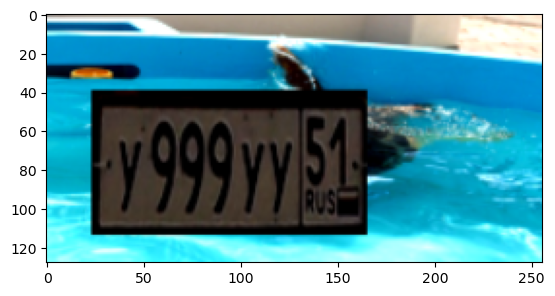

In [13]:
plt.imshow(number_data[0]['img'].permute(1,2,0))

In [14]:
number_data[0]['img'].permute(1,2,0).shape

torch.Size([128, 256, 3])

In [15]:
class ResnetBlock(Module):
    def __init__(self,input_size,output_size,stride=1,downsample=None):#downsample нужно в случае понижения размерности блока):
        super().__init__()
        self.act=nn.ReLU(inplace=True)
        self.conv0=nn.Conv2d(input_size,output_size,kernel_size=3,stride=stride,padding=1)
        self.norm0=nn.BatchNorm2d(output_size)

        self.conv1=nn.Conv2d(output_size,output_size,kernel_size=3,stride=1,padding=1)
        self.norm1=nn.BatchNorm2d(output_size)

        self.downsample=downsample
    def forward(self,x):
        out=self.conv0(x)
        out=self.norm0(out)
        out=self.act(out)
        out=self.conv1(out)
        out=self.norm1(out)
        if self.downsample:
            x=self.downsample(x)
        out+=x
        out=self.act(out)

        return out

In [16]:
def make_layers(block,cnt,input_size,output_size,stride=1,downsample=False):
    blocks=[]

    if downsample or input_size!=output_size or stride!=1:
        downsample=nn.Sequential(
            nn.Conv2d(input_size,output_size,1,stride,bias=False),
            nn.BatchNorm2d(output_size)
        )

    blocks.append(block(input_size,output_size,stride,downsample))    
    for i in range(1,cnt):
        blocks.append(block(output_size,output_size))

    return nn.Sequential(*blocks)
    

In [17]:
class Resnet34(Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()

        self.initial_lay=nn.Sequential(
            nn.Conv2d(input_size,hidden_size,kernel_size=7,stride=2,padding=3),
            nn.BatchNorm2d(hidden_size),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3,stride=2,padding=1)
        )

        self.lay0=make_layers(block=ResnetBlock,cnt=3,input_size=hidden_size,output_size=hidden_size,downsample=False)
        self.lay1=make_layers(block=ResnetBlock,cnt=4,input_size=hidden_size,output_size=hidden_size*2,stride=(2,1),downsample=True)
        self.lay2=make_layers(block=ResnetBlock,cnt=6,input_size=hidden_size*2,output_size=hidden_size*4,stride=(2,1),downsample=True)
        self.lay3=make_layers(block=ResnetBlock,cnt=3,input_size=hidden_size*4,output_size=hidden_size*8,stride=(2,1),downsample=True)

        self.avg_pool=nn.AdaptiveAvgPool2d((1,None))
        
    def forward(self,x):
        #print(x.shape)
        out=self.initial_lay(x)
        #print(out.shape)
        #print('СЛОИ:')
        out=self.lay0(out)
        #print(out.shape)
        out=self.lay1(out)
        #print(out.shape)
        out=self.lay2(out)
        #print(out.shape)
        out=self.lay3(out)
        #print(out.shape)

        final_out=self.avg_pool(out)
        #print(final_out.shape)
        return final_out

In [18]:
class CRNN(Module):
    def __init__(self,input_size,hidden_size,out_size):
        super().__init__()

        self.stn=STN()

        self.cnn=Resnet34(input_size,hidden_size)
        self.rnn=nn.LSTM(hidden_size*8,hidden_size*4,num_layers=1,bidirectional=True)
        self.final_lay=nn.Sequential(    
            nn.Dropout(p=0.2),
            nn.Linear(hidden_size*8,out_size)
        )
                
    def forward(self,x):
        x=self.stn(x)
        out=self.cnn(x)

        out=out.squeeze(2).permute(2,0,1)
        out,_=self.rnn(out)

        out=self.final_lay(out)
        return out,x

In [19]:
class STN(Module):
    def __init__(self):
        super().__init__()

        self.localization= nn.Sequential(
            nn.Conv2d(3,8,kernel_size=7),
            nn.MaxPool2d(2,stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(8,10,kernel_size=5),
            nn.MaxPool2d(2,stride=2),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((3,3))
        )

        

        self.fc_loc=nn.Sequential(
            nn.Linear(10*3*3,32),
            nn.ReLU(inplace=True),
            nn.Linear(32,3*2)
        )
        #print(self.fc_loc)
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))
        #print(self.fc_loc)
    def forward(self,x):
        xs=self.localization(x)
        xs=xs.view(-1,10*3*3)
        theta=self.fc_loc(xs)
        theta=theta.view(-1,2,3)

        grid=F.affine_grid(theta,x.size())
        x=F.grid_sample(x,grid)
        return x
        

In [20]:
loss_fn=nn.CTCLoss(blank=0)
model=CRNN(input_size=3,hidden_size=64,out_size=len(alphabet)).to(device)


if f'crnn_weights.pth' in os.listdir('../VehicleNumberData/VNR_Data/weights/'):
    weights_dict=torch.load(f'../VehicleNumberData/VNR_Data/weights/crnn_weights.pth',weights_only=True)
    model.load_state_dict(weights_dict)
    print('Веса обнаружены')
optimizer=AdamW(model.parameters())

Веса обнаружены


In [ ]:
import torch
from tqdm import tqdm


model.train()

dataloader=number_dataloader
epochs=1
losses=[]
for epoch in range(epochs):
    for batch in (pbar:=tqdm(dataloader)):
        optimizer.zero_grad()
        img,label,label_len=batch
        pred,resized_img=model(img.to(device))
    
        T = pred.size(0)
        N = pred.size(1)
        input_len = torch.full(size=(N,), fill_value=T, dtype=torch.int32)
        
        pred=pred.log_softmax(dim=2)
        loss=loss_fn(pred,label,input_len,label_len)
        loss.backward()
        loss_item=loss.item()
        losses.append(loss_item)
        optimizer.step()
        pbar.set_description(f"loss: {loss_item}")
    try:
        torch.save(model.state_dict(),r'../VehicleNumberData/VNR_Data/weights/crnn_weights.pth')
    except:
        print('Ошибка загрузки')
    print(f'mean_loss: {sum(losses)/len(losses)}')


  0%|                                            | 0/2776 [00:00<?, ?it/s]/tmp/ipykernel_2937/3915059033.py:32: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  grid=F.affine_grid(theta,x.size())
/tmp/ipykernel_2937/3915059033.py:33: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  x=F.grid_sample(x,grid)
loss: 0.04131064563989639:   6%|▍      | 162/2776 [00:32<08:46,  4.96it/s]

In [26]:
def ctc_decoder(pred_string):
    new_string=[]
    perv_symb=-1
    for symb in pred_string:
        if symb.item()!=perv_symb:
            if symb.item()!=0:
                new_string.append(int2let[symb.item()])
        perv_symb=symb
    return ''.join(new_string)

In [27]:
number_eval_data=NumberDataset(path='//home/artemybombastic/MyGit/VehicleNumberData/VNR_Data/val',number_len=9,let2int=let2int,background_path='/home/artemybombastic/MyGit/VehicleNumberData/VNR_Data/background/')
number_eval_dataloader=DataLoader(number_eval_data,batch_size=16,shuffle=False,drop_last=True,collate_fn=collate_fn)


In [28]:
#0.9368852459016394



model.eval()

dataloader=number_eval_dataloader
all_accuracy=[]
for batch in (pbar:=tqdm(dataloader)):
    img,label,label_len=batch
    pred,resized_img=model(img.to(device))

    label=[num.item() for num in label]
    corected_label=[]
    for lenght in label_len:
        new_label=label[:lenght]
        new_label=[int2let[num] for num in new_label]
        new_label=''.join(new_label)
        corected_label.append(new_label)
        label=label[lenght:]

    corected_pred=[ctc_decoder(word) for word in pred.argmax(dim=2).permute(1,0)]
    accuracy=[corected_label[i]==corected_pred[i] for i in range(16)]
    accuracy=sum(accuracy)/len(accuracy)
    
    all_accuracy.append(accuracy)
    pbar.set_description(f"accuracy: {accuracy}")
print(f'Средняя точность на тестовой выборке равна {sum(all_accuracy)/len(all_accuracy)}')

  0%|                                             | 0/305 [00:00<?, ?it/s]/tmp/ipykernel_2937/3915059033.py:32: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  grid=F.affine_grid(theta,x.size())
/tmp/ipykernel_2937/3915059033.py:33: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  x=F.grid_sample(x,grid)
accuracy: 0.9375: 100%|█████████████████| 305/305 [00:42<00:00,  7.22it/s]

Средняя точность на тестовой выборке равна 0.9055327868852459


  0%|                                             | 0/305 [00:00<?, ?it/s]/tmp/ipykernel_3424/3915059033.py:32: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  grid=F.affine_grid(theta,x.size())
/tmp/ipykernel_3424/3915059033.py:33: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  x=F.grid_sample(x,grid)


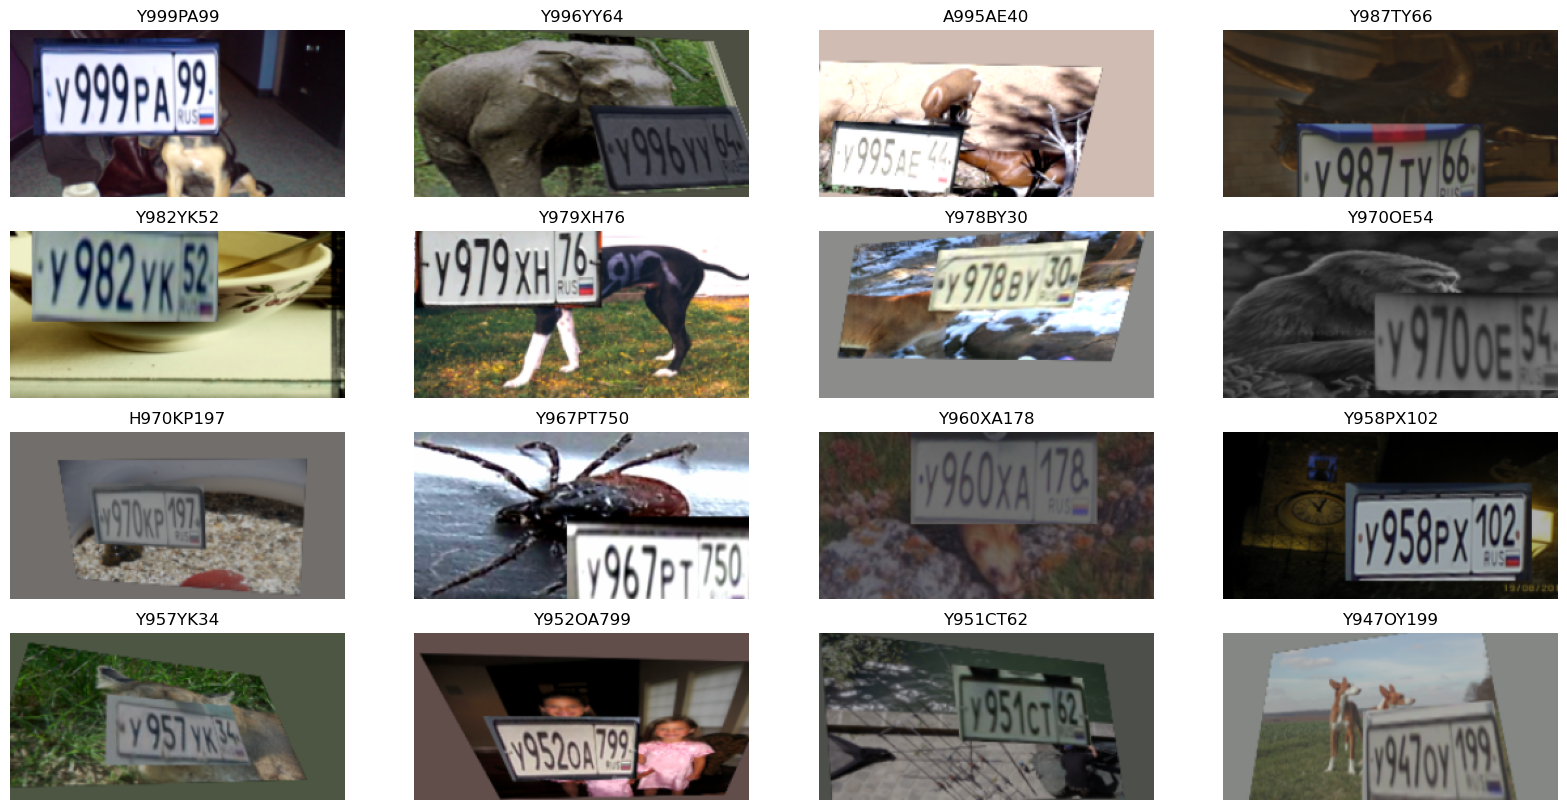

  0%|                                             | 0/305 [00:00<?, ?it/s]


In [41]:
model.eval()
for batch in (pbar:=tqdm(number_eval_dataloader)):
    img,label,label_len=batch
    pred,resized_img=model(img.to(device))

    label=[num.item() for num in label]
    corected_label=[]
    for lenght in label_len:
        new_label=label[:lenght]
        new_label=[int2let[num] for num in new_label]
        new_label=''.join(new_label)
        corected_label.append(new_label)
        label=label[lenght:]

    corected_pred=[ctc_decoder(word) for word in pred.argmax(dim=2).permute(1,0)]
    accuracy=[corected_label[i]==corected_pred[i] for i in range(16)]
    accuracy=sum(accuracy)/len(accuracy)
    fig, ax = plt.subplots(4, 4,figsize=(20,10))
    k=0
    for i in range(4):
        for j in range(4):
            ax[i,j].imshow(img[k].cpu().permute(1,2,0).detach()); ax[i,j].set_title(corected_pred[k])
            ax[i,j].axis('off')
            k+=1
    plt.show()
    break

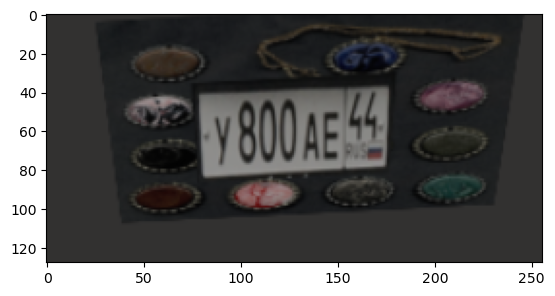

In [29]:
plt.imshow(img[4].cpu().detach().permute(1,2,0))

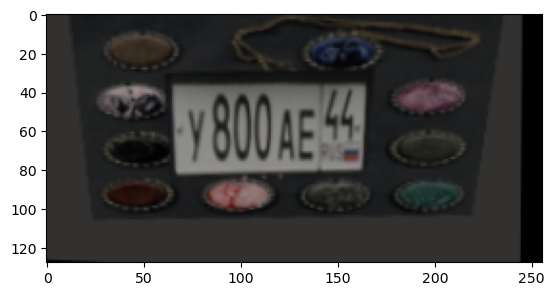

In [30]:
plt.imshow(resized_img[4].cpu().detach().permute(1,2,0))

In [42]:
resized_img

tensor([[[[0.5590, 0.5658, 0.5744,  ..., 0.0000, 0.0000, 0.0000],
          [0.5585, 0.5710, 0.5789,  ..., 0.0000, 0.0000, 0.0000],
          [0.5561, 0.5741, 0.5756,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0186, 0.0196, 0.0197,  ..., 0.0000, 0.0000, 0.0000],
          [0.0175, 0.0204, 0.0207,  ..., 0.0000, 0.0000, 0.0000],
          [0.0232, 0.0228, 0.0228,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.3145, 0.3108, 0.3097,  ..., 0.0000, 0.0000, 0.0000],
          [0.3112, 0.3125, 0.3057,  ..., 0.0000, 0.0000, 0.0000],
          [0.3082, 0.3121, 0.3052,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0304, 0.0314, 0.0315,  ..., 0.0000, 0.0000, 0.0000],
          [0.0293, 0.0322, 0.0324,  ..., 0.0000, 0.0000, 0.0000],
          [0.0350, 0.0346, 0.0346,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.1242, 0.1246, 0.1339,  ..., 0.0000, 0.0000, 0.0000],
          [0.1266, 0.1307, 0.1334,  ..., 0.0000, 0.0000, 0.0000],
          [0.1241, 0.1307, 0.1288,  ..., 0

In [43]:
corected_pred

['Y999PA99',
 'Y996YY64',
 'Y995AE44',
 'Y987TY66',
 'Y982YK52',
 'Y979XH76',
 'Y978BY30',
 'Y970OE54',
 'Y970KP197',
 'Y967PT750',
 'Y960XA178',
 'Y958PX102',
 'Y957YK34',
 'Y952OA799',
 'T951CT62',
 'T947OY199']